**Plot 1**<br>
The aesthetics being used are:
- x-axis: income (per person gdp/per capita)
- y-axis: life expectancy (years)
- size: population
- color: location
- points: country<br>
It shows the different income levels at the top of the graph as well as that this is for 2010.

In [1]:
import pandas as pd                       # the library, nicknamed pd
from plotnine import *                    # every plotting function in plotnine: ggplot, aes, geom_*, ...

print(type(pd))                           # pd is a *module* (a loaded library)
print(pd.__version__)                     # which version got loaded
ggplot  

q1data = pd.read_csv("q1data.csv")
q1data.head()

<class 'module'>
3.0.3


,income,life_exp,population,year,country,four_regions,six_regions,eight_regions,world_bank_region
0,1910.0,61.0,29200000.0,2010,Afghanistan,asia,south_asia,asia_west,South Asia
1,11100.0,78.1,2950000.0,2010,Albania,europe,europe_central_asia,europe_east,Europe & Central Asia
2,11100.0,74.7,36000000.0,2010,Algeria,africa,middle_east_north_africa,africa_north,Middle East & North Africa
3,46900.0,81.9,84500.0,2010,Andorra,europe,europe_central_asia,europe_west,Europe & Central Asia
4,7680.0,60.8,23400000.0,2010,Angola,africa,sub_saharan_africa,africa_sub_saharan,Sub-Saharan Africa


/opt/anaconda3/lib/python3.14/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 7 rows containing missing values.
/opt/anaconda3/lib/python3.14/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 7 rows containing missing values.


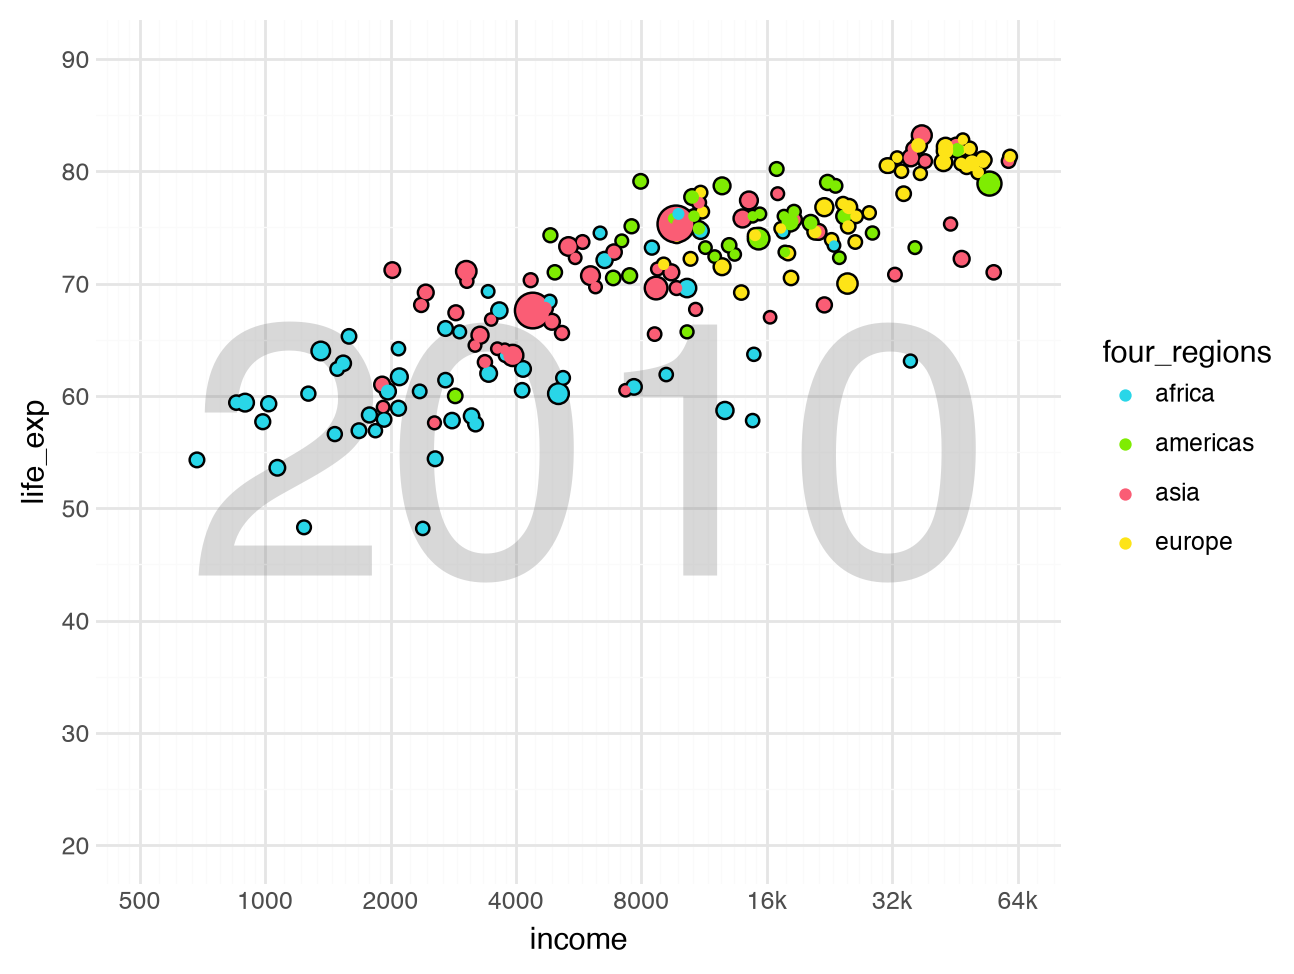

In [47]:
from plotnine import *

q1data = q1data.dropna(subset=["income", "life_exp", "population", "four_regions", "country"])

x_breaks = [500, 1000, 2000, 4000, 8000, 16000, 32000, 64000]
x_labels = ["500", "1000", "2000", "4000", "8000", "16k", "32k", "64k"]
y_breaks = [20, 30, 40, 50, 60, 70, 80, 90]
y_labels = ["20", "30", "40", "50", "60", "70", "80", "90"]

four_region_colors = {
    "asia": "#fa5d75",
    "europe": "#fde417",
    "africa": "#29d6e8",
    "americas": "#7fec02"
}

(ggplot(q1data, aes(x = "income", y = "life_exp", color = "four_regions", size = "population"))
 + annotate("text", x=6000, y=55, label="2010", size=130, color="grey", alpha=0.3)
 + geom_point(color = "black", stroke = 1)
 + geom_point()
 + scale_color_manual(four_region_colors)
 + scale_x_log10(breaks=x_breaks,labels=x_labels, limits=[500,64000])
 + scale_y_continuous(breaks=y_breaks, labels=y_labels, limits=[20, 90])
 + guides(size=False)
 + theme_minimal()
)




**If we do a boxplot instead, it no longer shows the relationship between income and life expectancy. There is no population-size info and no individual country identity. It can only show the distribution of one variable at a time, grouped by region. You would have to make 2 different plots to see both.**

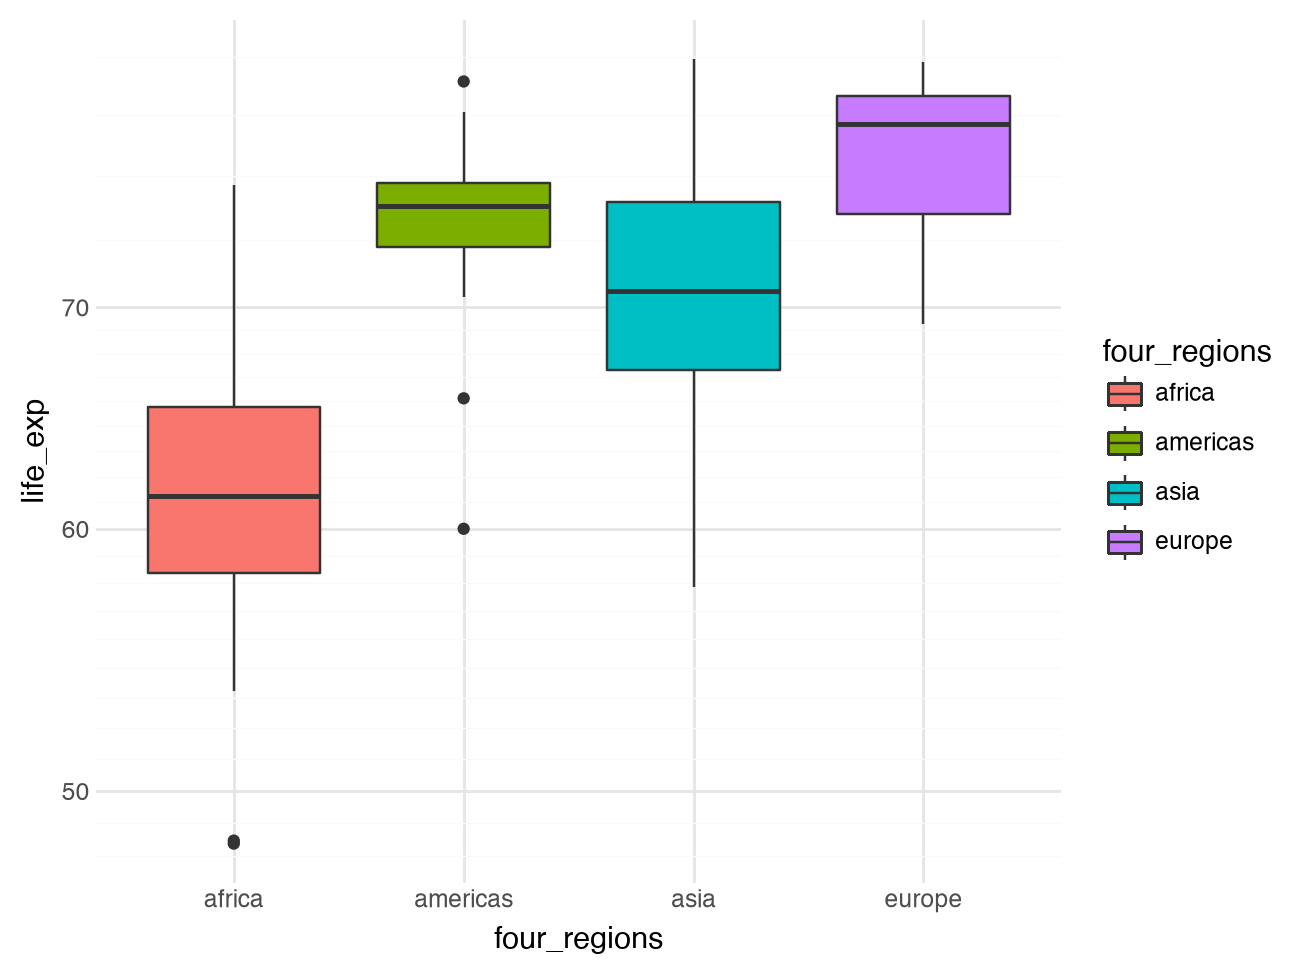

In [ ]:
from plotnine import *

q1data = q1data.dropna(subset=["income", "life_exp", "population", "four_regions", "country"])

x_breaks = [500, 1000, 2000, 4000, 8000, 16000, 32000, 64000]
x_labels = ["500", "1000", "2000", "4000", "8000", "16k", "32k", "64k"]
y_breaks = [20, 30, 40, 50, 60, 70, 80, 90]
y_labels = ["20", "30", "40", "50", "60", "70", "80", "90"]

four_region_colors = {
    "asia": "#fa5d75",
    "europe": "#fde417",
    "africa": "#29d6e8",
    "americas": "#7fec02"
}

(ggplot(q1data, aes(x="four_regions", y="life_exp", fill="four_regions"))
 + geom_boxplot()
 + scale_y_log10()
 + theme_minimal()
)



**Plot 2**<br>
The aesthetics being used are:
- x-axis: Exports (/% of GDP)
- y-axis: Imports (/% of GDP)
- size: energy use
- color: location
- points: country<br>
It shows that this is for 1997.

In [3]:
q2data = pd.read_csv("q2data.csv")
q2data.head()

,imports,exports,energy,year,country,four_regions,six_regions,eight_regions,world_bank_region
0,NaN,NaN,NaN,1997,Afghanistan,asia,south_asia,asia_west,South Asia
1,36.7,11.5,427,1997,Albania,europe,europe_central_asia,europe_east,Europe & Central Asia
2,22.5,22.6,825,1997,Algeria,africa,middle_east_north_africa,africa_north,Middle East & North Africa
3,NaN,NaN,NaN,1997,American Samoa,NaN,NaN,NaN,NaN
4,NaN,NaN,434,1997,Angola,africa,sub_saharan_africa,africa_sub_saharan,Sub-Saharan Africa


/opt/anaconda3/lib/python3.14/site-packages/plotnine/scales/scale_size.py:46: PlotnineWarning: Using size for a discrete variable is not advised.
/opt/anaconda3/lib/python3.14/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 92 rows containing missing values.
/opt/anaconda3/lib/python3.14/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 92 rows containing missing values.


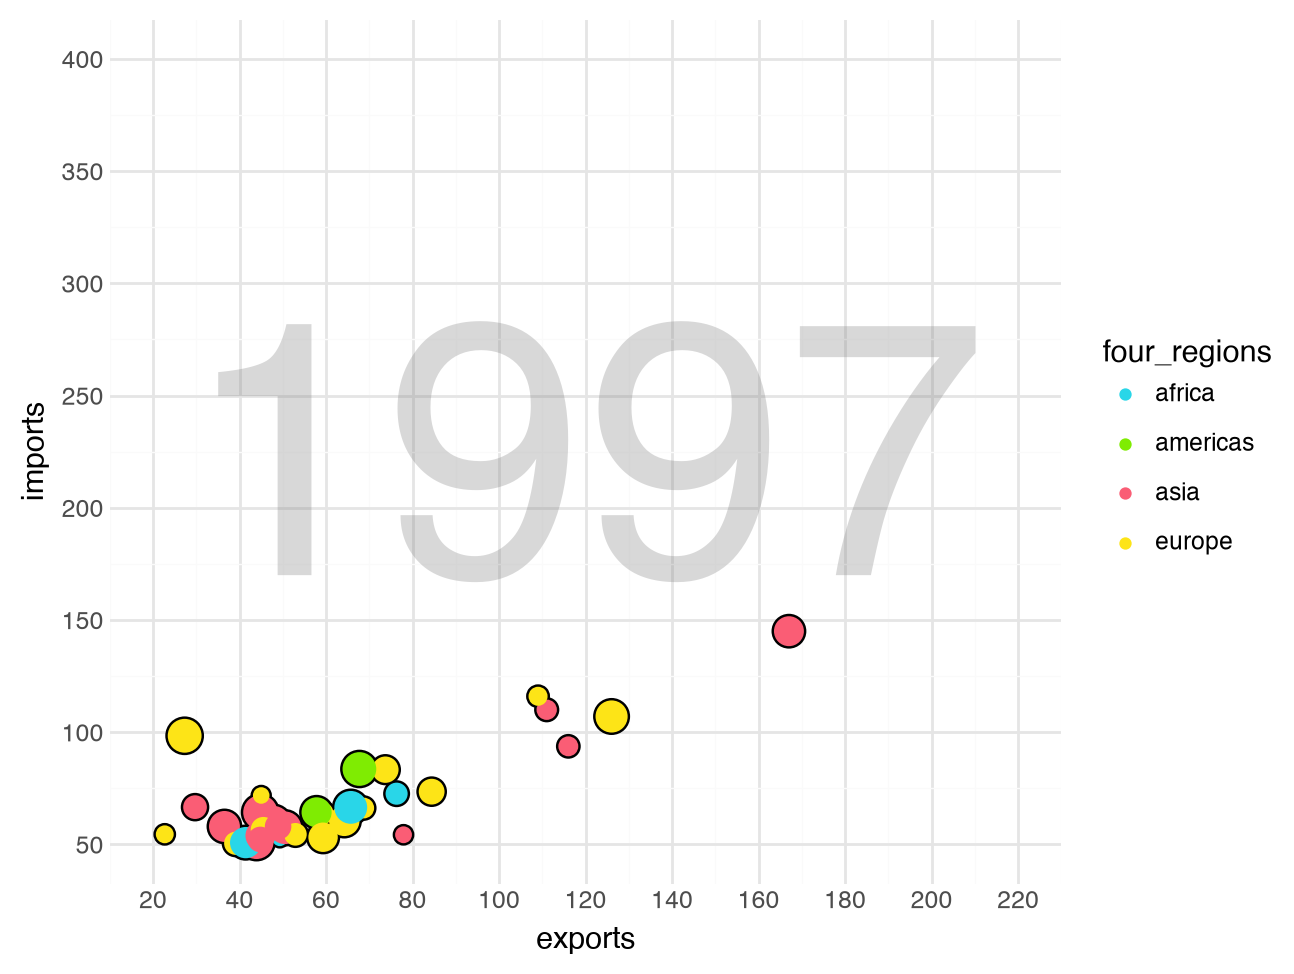

In [53]:
# from plotnine import scale_x_continuous, scale_y_continuous, guides

#q2data["energy"] = q2data["energy"].astype(int)
q2data = q2data.dropna(subset=["exports", "imports", "energy", "four_regions", "country"])

x2_breaks = [20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220]
x2_labels = ["20", "40", "60", "80", "100", "120", "140", "160", "180", "200", "220"]
y2_breaks = [50, 100, 150, 200, 250, 300, 350, 400]
y2_labels = ["50", "100", "150", "200", "250", "300", "350", "400"]

four_region_colors = {
    "asia": "#fa5d75",
    "europe": "#fde417",
    "africa": "#29d6e8",
    "americas": "#7fec02"
}

(ggplot(q2data, aes(x = "exports", y = "imports", color = "four_regions", size = "energy"))
 + annotate("text", x=120, y=225, label="1997", size=130, color="grey", alpha=0.3)
 + geom_point(color = "black", stroke = 1)
 + geom_point()
 + scale_color_manual(four_region_colors)
 + scale_x_continuous(breaks=x2_breaks, limits=(20,220))
 + scale_y_continuous(breaks=y2_breaks, limits=(50,400))
 + guides(size=False)
 + theme_minimal()
 
)

**If we do a density plot. It shows where points are most concentrated for each region. But it can only handle one variable, imports or exports. You would have to make 2 different density plots to see each exports and imports.**

/opt/anaconda3/lib/python3.14/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_density : Removed 15 rows containing non-finite values.


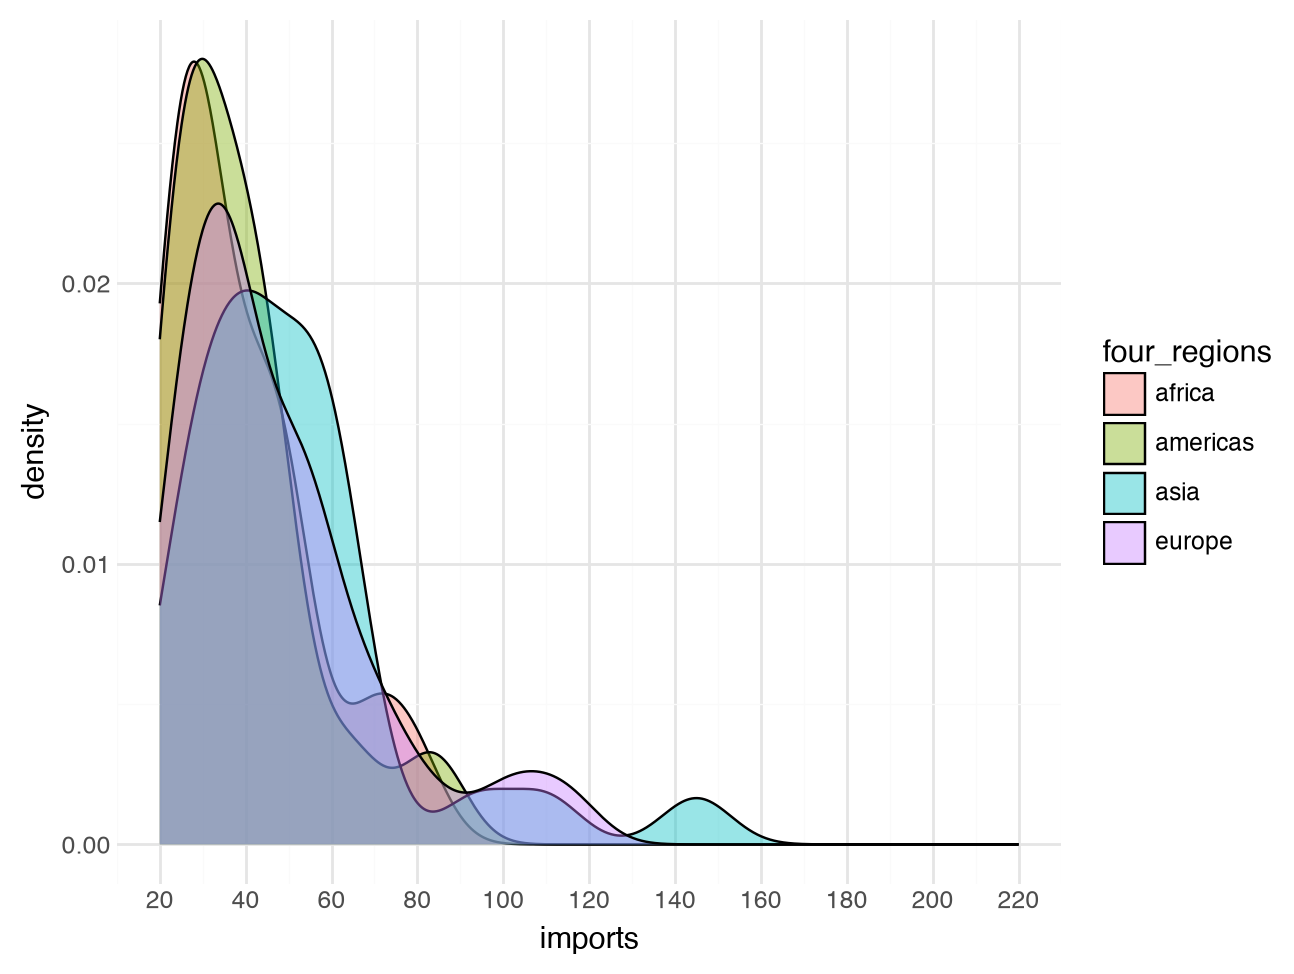

In [ ]:
(ggplot(q2data, aes(x="exports", fill="four_regions"))
 + geom_density(alpha=0.4)
 + scale_x_continuous(breaks=x2_breaks, limits=(20,220))
 + theme_minimal()
)


**Plot 3**<br>
The aesthetics being used are:
- x-axis: individuals using the internet
- y-axis: GDP/Capita
- size: income
- color: location
- points: country<br>
It shows that this is for 2001. The Y-axis is drawn to show the smaller/larger gaps btwn bins

In [5]:
q3data = pd.read_csv("q3data.csv")
q3data.head()

,internet_users,gdp,income,year,country,four_regions,six_regions,eight_regions,world_bank_region
0,0.00456,330.0,1190.0,2001,Afghanistan,asia,south_asia,asia_west,South Asia
1,0.39000,2570.0,6780.0,2001,Albania,europe,europe_central_asia,europe_east,Europe & Central Asia
2,1.59000,3770.0,9230.0,2001,Algeria,africa,middle_east_north_africa,africa_north,Middle East & North Africa
3,NaN,10500.0,NaN,2001,American Samoa,NaN,NaN,NaN,NaN
4,11.30000,42600.0,35600.0,2001,Andorra,europe,europe_central_asia,europe_west,Europe & Central Asia


/opt/anaconda3/lib/python3.14/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 119 rows containing missing values.
/opt/anaconda3/lib/python3.14/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 119 rows containing missing values.


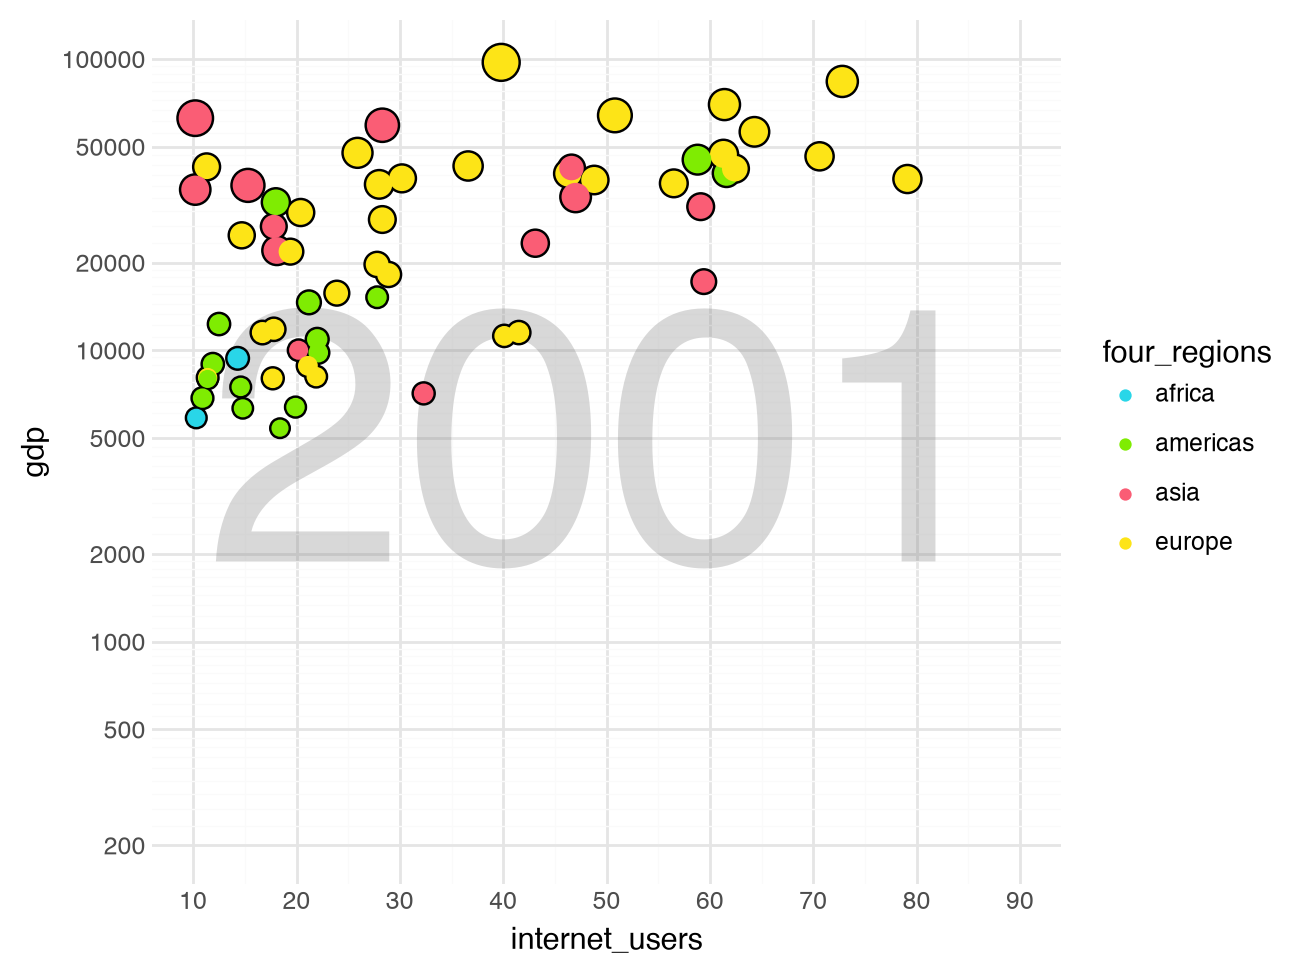

In [48]:
from plotnine.geoms import geom
from plotnine import *

q3data = q3data.dropna(subset=["internet_users", "gdp", "income", "four_regions", "country"])

x3_breaks = [10, 20, 30, 40, 50, 60, 70, 80, 90]
x3_labels = ["10", "20", "30", ""]
y3_breaks = [200, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000]
y3_labels = ["200", "500", "1000", "2000", "5000", "10k", "20k", "50k", "100k"]

four_region_colors = {
    "asia": "#fa5d75",
    "europe": "#fde417",
    "africa": "#29d6e8",
    "americas": "#7fec02"
}

#q3data = q3data.dropna(subset = ["income"])

(ggplot(q3data, aes(x = "internet_users", y = "gdp", color = "four_regions", size = "income"))
 + annotate("text", x=50, y=5000, label="2001", size=130, color="grey", alpha=0.3)
 + geom_point(color = "black", stroke = 1)
 + geom_point()
 + scale_color_manual(four_region_colors)
 + scale_x_continuous(breaks=x3_breaks, limits=(10, 90))
 + scale_y_log10(breaks=y3_breaks, limits=(200, 100000))
 + guides(size=False)
 + theme_minimal()
 
)

**If we did a violin plot, it is able to look at both internet_users and gdp by each region and income. It does show the full shape and density of the distribution. It shows median and inter quartile markers without neededing to do 2 different plots.**

/opt/anaconda3/lib/python3.14/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_ydensity : Removed 119 rows containing non-finite values.
/opt/anaconda3/lib/python3.14/site-packages/plotnine/positions/position.py:232: PlotnineWarning: position_dodge requires non-overlapping x intervals


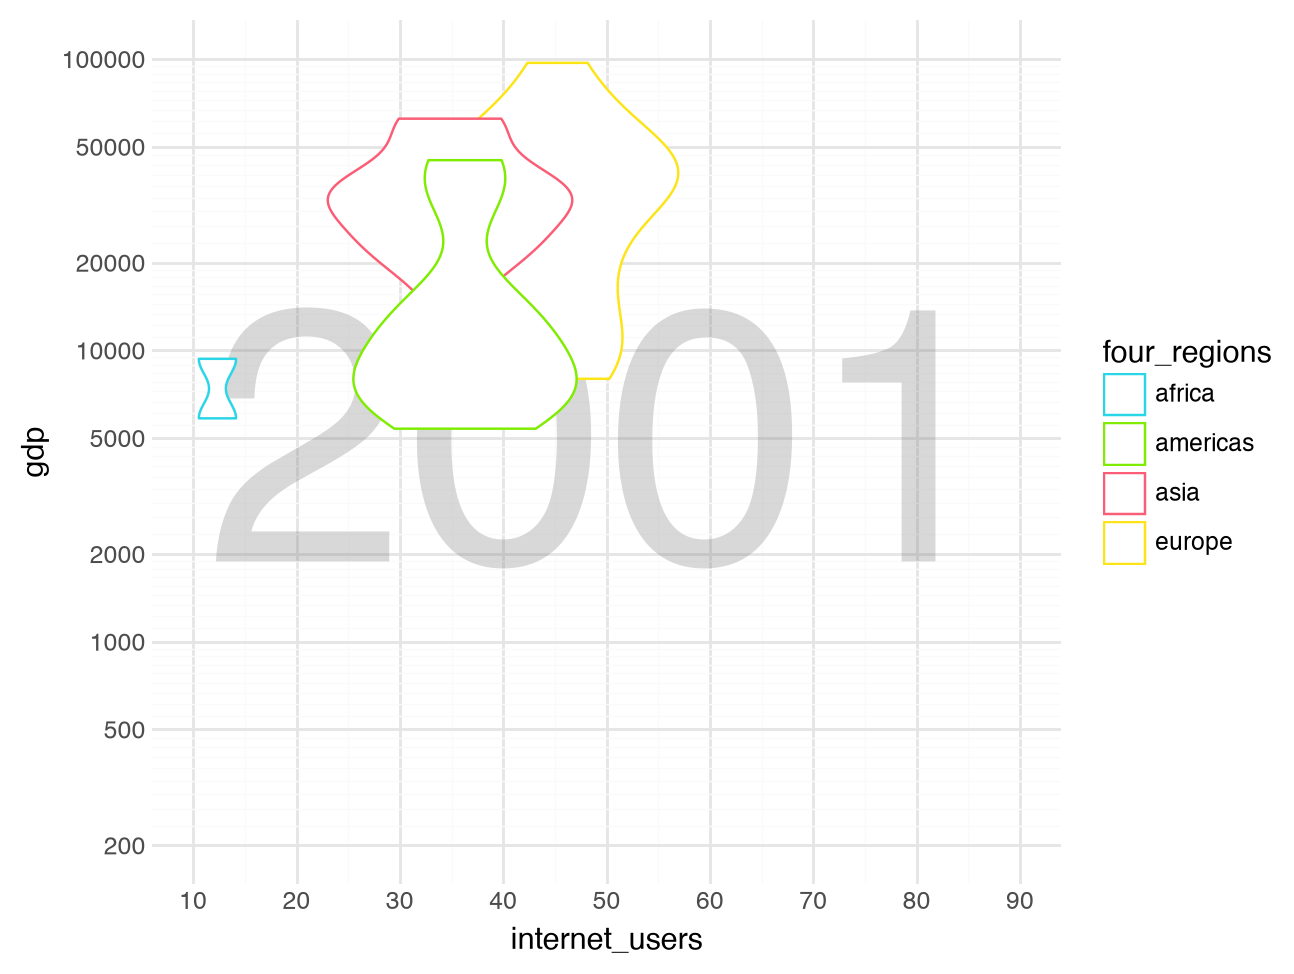

In [73]:
x3_breaks = [10, 20, 30, 40, 50, 60, 70, 80, 90]
x3_labels = ["10", "20", "30", ""]
y3_breaks = [200, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000]
y3_labels = ["200", "500", "1000", "2000", "5000", "10k", "20k", "50k", "100k"]

four_region_colors = {
    "asia": "#fa5d75",
    "europe": "#fde417",
    "africa": "#29d6e8",
    "americas": "#7fec02"
}

#q3data = q3data.dropna(subset = ["income"])

(ggplot(q3data, aes(x = "internet_users", y = "gdp", color = "four_regions", size = "income"))
 + annotate("text", x=50, y=5000, label="2001", size=130, color="grey", alpha=0.3)
 + geom_violin()
 + scale_color_manual(values = four_region_colors)
 + scale_x_continuous(breaks=x3_breaks, limits=(10, 90))
 + scale_y_log10(breaks=y3_breaks, limits=(200, 100000))
 + guides(size=False)
 + theme_minimal()
 
)